# Money Market Rates

## 1. Explore money-market rates

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# load the data
rates = pd.read_excel('../data/ref_rates.xlsx', sheet_name='data')
rates.head()

,date,DTB3,DFF,SOFR
0,2018-01-01,NaN,1.33,NaN
1,2018-01-02,1.42,1.42,NaN
2,2018-01-03,1.39,1.42,NaN
3,2018-01-04,1.39,1.42,NaN
4,2018-01-05,1.37,1.42,NaN


<Axes: xlabel='date'>

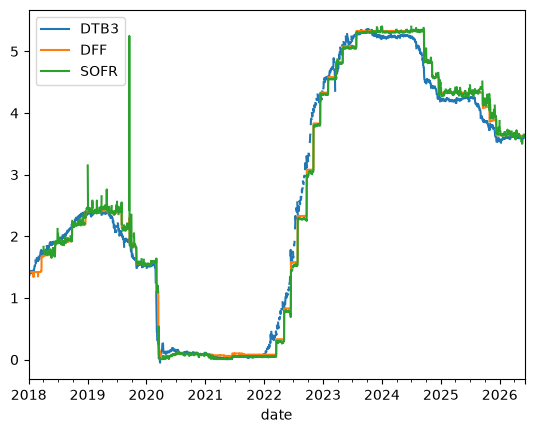

In [4]:
rates = rates.set_index('date', drop=True)
rates.plot()

In [6]:
# levels
rates.corr()

,DTB3,DFF,SOFR
DTB3,1.000000,0.994679,0.992898
DFF,0.994679,1.000000,0.999091
SOFR,0.992898,0.999091,1.000000


In [11]:
# differences
rates.pct_change().corr()

,DTB3,DFF,SOFR
DTB3,1.000000,0.023708,-0.008262
DFF,0.023708,1.000000,0.677746
SOFR,-0.008262,0.677746,1.000000


In [15]:
sofr = rates[['SOFR']].copy()
sofr.tail()

,SOFR
date,
2026-06-01,3.65
2026-06-02,3.63
2026-06-03,3.61
2026-06-04,3.62
2026-06-05,3.63


In [16]:
sofr_d1 = sofr.shift()
sofr_d1.tail()

,SOFR
date,
2026-06-01,NaN
2026-06-02,3.65
2026-06-03,3.63
2026-06-04,3.61
2026-06-05,3.62


In [21]:
import statsmodels.api as sm
sofr_dna = sofr.pct_change().dropna()
sofr_d1_dna = sofr_d1.pct_change().dropna()
inter_sofr = sofr_dna.index.intersection(sofr_d1_dna.index)
lr_sfr = sm.OLS(sofr_d1_dna.loc[inter_sofr], sm.add_constant(sofr_dna.loc[inter_sofr])).fit()
lr_sfr.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   SOFR   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     2.122
Date:                Fri, 04 Sep 2026   Prob (F-statistic):              0.146
Time:                        21:31:12   Log-Likelihood:                -44.442
No. Observations:                1154   AIC:                             92.88
Df Residuals:                    1152   BIC:                             103.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0141      0.007      1.897      0.058      -0.000       0.029
SOFR          -0.0437      0.030     -1.457      0.146      -0.103       0.015
==============================================================================
Omnibus:                     2101.686   Durbin-Watson:                   2.000
Prob(Omnibus):                  0.000   Jarque-Bera (JB):          2158744.104
Skew:                          12.684   Prob(JB):                         0.00
Kurtosis:                     213.362   Cond. No.                         4.05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [19]:
spy = pd.read_excel('../data/spy_data_daily.xlsx', sheet_name='prices')
spy = spy.set_index("date", drop=True)
spy.head()

,SPY,^IRX
date,,
1994-01-03,26.432665,3.03
1994-01-04,26.539318,3.08
1994-01-05,26.592653,3.07
1994-01-06,26.592653,3.05
1994-01-07,26.752617,3.01


In [22]:
spy_px = spy[["SPY"]]
spy_px_d1 = spy_px.shift()
spy_px_dna = spy_px.pct_change().dropna()
spy_px_d1_dna = spy_px_d1.pct_change().dropna()
inter_spy = spy_px_dna.index.intersection(spy_px_d1_dna.index)
lr_spy = sm.OLS(spy_px_d1_dna.loc[inter_spy], sm.add_constant(spy_px_dna.loc[inter_spy])).fit()
lr_spy.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    SPY   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                  0.007
Method:                 Least Squares   F-statistic:                     56.45
Date:                Fri, 04 Sep 2026   Prob (F-statistic):           6.38e-14
Time:                        21:31:51   Log-Likelihood:                 24669.
No. Observations:                8164   AIC:                        -4.933e+04
Df Residuals:                    8162   BIC:                        -4.932e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0005      0.000      3.971      0.000       0.000       0.001
SPY           -0.0829      0.011     -7.513      0.000      -0.104      -0.061
==============================================================================
Omnibus:                     1494.790   Durbin-Watson:                   2.004
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            40051.363
Skew:                           0.002   Prob(JB):                         0.00
Kurtosis:                      13.851   Cond. No.                         84.5
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

# Treasuries

In [25]:
treasuries = pd.read_excel('../data/treasury_quotes_2020-09-30.xlsx', sheet_name='quotes')
# treasuries = treasuries.set_index('date', drop=True)
treasuries.head()

,KYTREASNO,type,quote date,issue date,maturity date,ttm,accrual fraction,cpn rate,bid,ask,price,accrued int,dirty price,ytm,total size,public size,duration
0,207503,bill,2020-09-30,2020-04-02,2020-10-01,0.002738,0.994524,0.000,99.999853,99.999881,99.999867,0.000000,99.999867,0.000487,1.747520e+11,NaN,0.002740
1,207521,bill,2020-09-30,2020-05-05,2020-10-06,0.016427,0.967146,0.000,99.999000,99.999167,99.999083,0.000000,99.999083,0.000558,1.363870e+11,NaN,0.016438
2,207427,bill,2020-09-30,2019-10-10,2020-10-08,0.021903,0.956194,0.000,99.998778,99.999000,99.998889,0.000000,99.998889,0.000507,2.066680e+11,NaN,0.021918
3,207535,bill,2020-09-30,2020-05-12,2020-10-13,0.035592,0.928816,0.000,99.997653,99.998014,99.997833,0.000000,99.997833,0.000609,1.352900e+11,NaN,0.035616
4,207146,note,2020-09-30,2017-10-15,2020-10-15,0.041068,0.918033,1.625,100.039062,100.078125,100.058594,0.745902,100.804495,0.001934,2.399600e+10,2.091800e+10,0.041096


<Axes: xlabel='maturity date'>

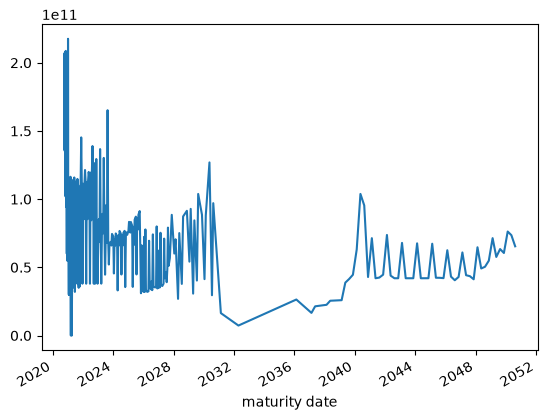

In [31]:
treas_ttl_size_by_mature = treasuries.groupby(by="maturity date")['total size'].sum()
treas_ttl_size_by_mature.plot()

<Axes: xlabel='maturity date'>

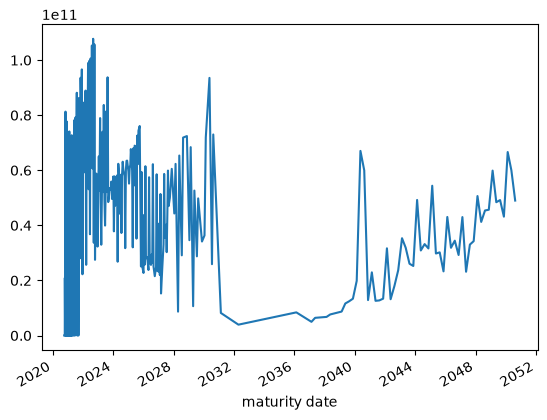

In [33]:
treas_ttl_pubsize_by_mature = treasuries.groupby(by="maturity date")['public size'].sum()
treas_ttl_pubsize_by_mature.plot()

In [36]:
pd.pivot_table(
    treasuries,
    index="maturity date",
    values="total size",
    aggfunc="sum"
)

,total size
maturity date,
2020-10-01,1.747520e+11
2020-10-06,1.363870e+11
2020-10-08,2.066680e+11
2020-10-13,1.352900e+11
2020-10-15,2.074920e+11
...,...
2049-08-15,6.339600e+10
2049-11-15,6.050500e+10
2050-02-15,7.624800e+10


In [37]:
pd.pivot_table(
    treasuries,
    index="maturity date",
    values="public size",
    aggfunc="sum"
)

,public size
maturity date,
2020-10-01,0.000000e+00
2020-10-06,0.000000e+00
2020-10-08,0.000000e+00
2020-10-13,0.000000e+00
2020-10-15,2.091800e+10
...,...
2049-08-15,4.918300e+10
2049-11-15,4.316800e+10
2050-02-15,6.662400e+10


In [38]:
treasuries.head()

,KYTREASNO,type,quote date,issue date,maturity date,ttm,accrual fraction,cpn rate,bid,ask,price,accrued int,dirty price,ytm,total size,public size,duration
0,207503,bill,2020-09-30,2020-04-02,2020-10-01,0.002738,0.994524,0.000,99.999853,99.999881,99.999867,0.000000,99.999867,0.000487,1.747520e+11,NaN,0.002740
1,207521,bill,2020-09-30,2020-05-05,2020-10-06,0.016427,0.967146,0.000,99.999000,99.999167,99.999083,0.000000,99.999083,0.000558,1.363870e+11,NaN,0.016438
2,207427,bill,2020-09-30,2019-10-10,2020-10-08,0.021903,0.956194,0.000,99.998778,99.999000,99.998889,0.000000,99.998889,0.000507,2.066680e+11,NaN,0.021918
3,207535,bill,2020-09-30,2020-05-12,2020-10-13,0.035592,0.928816,0.000,99.997653,99.998014,99.997833,0.000000,99.997833,0.000609,1.352900e+11,NaN,0.035616
4,207146,note,2020-09-30,2017-10-15,2020-10-15,0.041068,0.918033,1.625,100.039062,100.078125,100.058594,0.745902,100.804495,0.001934,2.399600e+10,2.091800e+10,0.041096


In [ ]:
by_type = pd.pivot_table(
    data=treasuries,
    columns="type",
    index="maturity date",
    values="total size",
    aggfunc="sum"
)
by_type
# n_col = len(by_type.columns)
# fig, ax = plt.subplots(np.ceil(n_col//2), 2)
# for i, col in enumerate(by_type.columns):
#     r, c = i//2, i%2
#     print(r, c)
#     ax[r][c].plot(col)

type,TIPS bond,TIPS note,bill,bond,note
maturity date,,,,,
2020-10-01,NaN,NaN,1.747520e+11,NaN,NaN
2020-10-06,NaN,NaN,1.363870e+11,NaN,NaN
2020-10-08,NaN,NaN,2.066680e+11,NaN,NaN
2020-10-13,NaN,NaN,1.352900e+11,NaN,NaN
2020-10-15,NaN,NaN,1.834960e+11,NaN,2.399600e+10
...,...,...,...,...,...
2049-08-15,NaN,NaN,NaN,6.339600e+10,NaN
2049-11-15,NaN,NaN,NaN,6.050500e+10,NaN
2050-02-15,1.572700e+10,NaN,NaN,6.052100e+10,NaN


In [64]:
plt.rcParams.update({
    "figure.facecolor": "#f5f5f5",
    "axes.facecolor": "#ffffff",
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})
plt.style.use("dark_background")

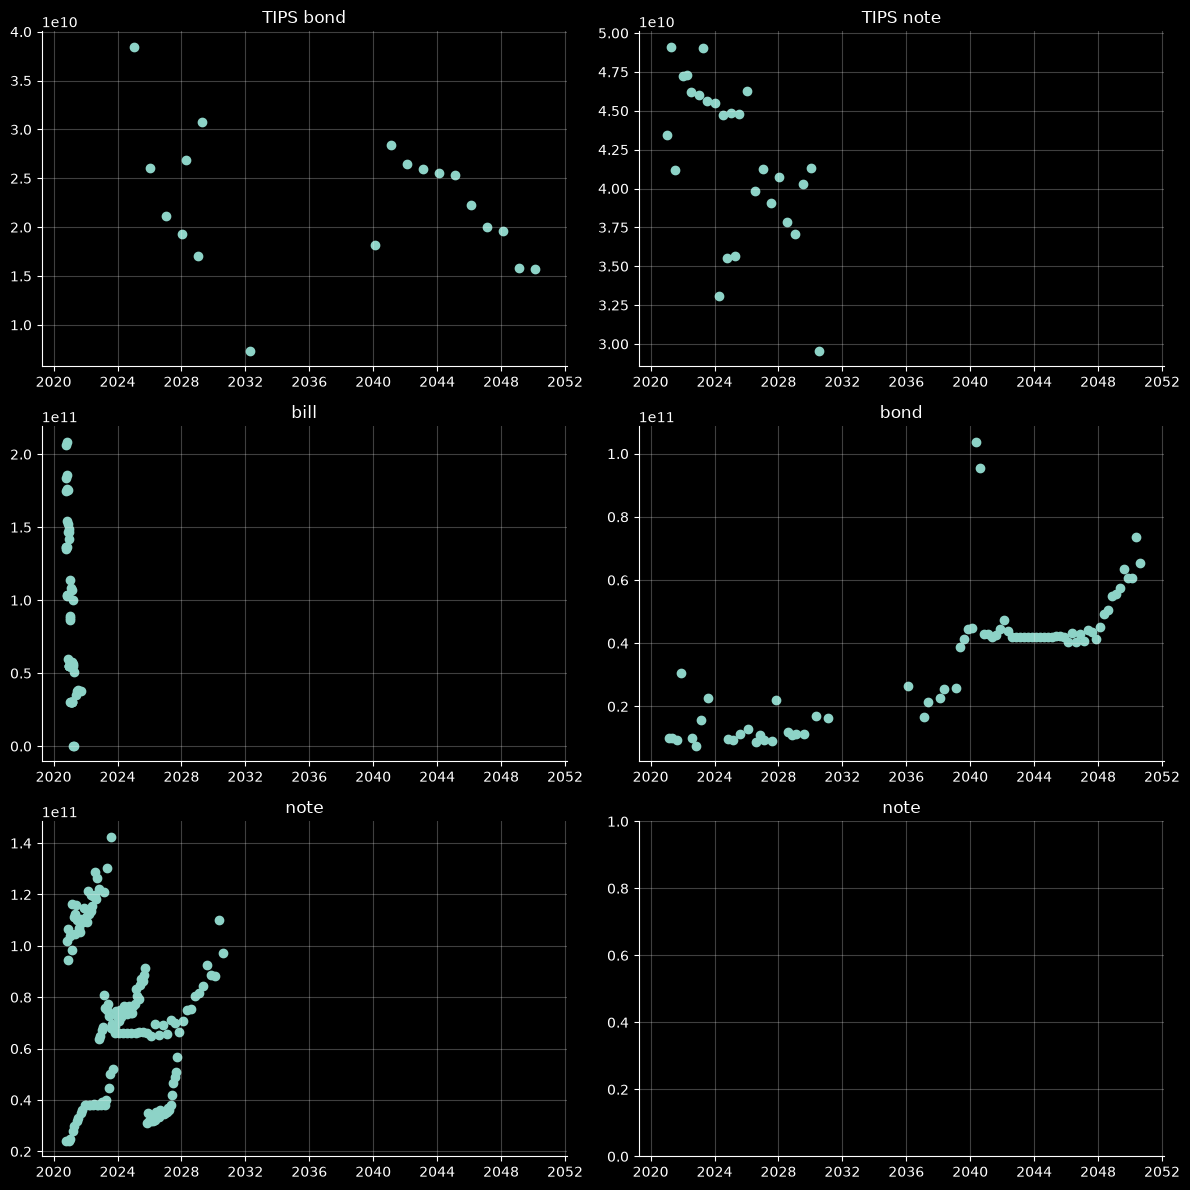

In [65]:
n_col = len(by_type.columns)
fig, ax = plt.subplots(int(np.ceil(n_col/2)), 2, 
                       figsize=(12, 12),
                       sharex=True)



# print(len(ax))
for i, col in enumerate(by_type.columns):
    r, c = i//2, i%2
    ax[r][c].scatter(by_type.index, by_type[col])
    ax[r][c].set_title(col)
    ax[r][c].tick_params(
        axis="x",
        labelbottom=True
    )
    ax[r][c].tick_params(
        axis="y",
        labelbottom=True
    )
    plt.tight_layout()
    plt.title(col)

In [66]:
treasuries.head()

,KYTREASNO,type,quote date,issue date,maturity date,ttm,accrual fraction,cpn rate,bid,ask,price,accrued int,dirty price,ytm,total size,public size,duration
0,207503,bill,2020-09-30,2020-04-02,2020-10-01,0.002738,0.994524,0.000,99.999853,99.999881,99.999867,0.000000,99.999867,0.000487,1.747520e+11,NaN,0.002740
1,207521,bill,2020-09-30,2020-05-05,2020-10-06,0.016427,0.967146,0.000,99.999000,99.999167,99.999083,0.000000,99.999083,0.000558,1.363870e+11,NaN,0.016438
2,207427,bill,2020-09-30,2019-10-10,2020-10-08,0.021903,0.956194,0.000,99.998778,99.999000,99.998889,0.000000,99.998889,0.000507,2.066680e+11,NaN,0.021918
3,207535,bill,2020-09-30,2020-05-12,2020-10-13,0.035592,0.928816,0.000,99.997653,99.998014,99.997833,0.000000,99.997833,0.000609,1.352900e+11,NaN,0.035616
4,207146,note,2020-09-30,2017-10-15,2020-10-15,0.041068,0.918033,1.625,100.039062,100.078125,100.058594,0.745902,100.804495,0.001934,2.399600e+10,2.091800e+10,0.041096


In [75]:
type_agg = pd.pivot_table(
    data=treasuries,
    columns="type",
    values="total size",
    aggfunc="sum"
).T
type_agg

,total size
type,
TIPS bond,4.305310e+11
TIPS note,1.092660e+12
bill,5.028905e+12
bond,2.673465e+12
note,1.066373e+13


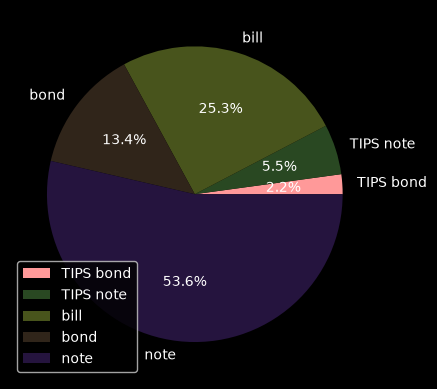

In [82]:
colors = ['#ff9999',"#294822","#48541C","#30251a", "#25143e"]
plt.pie(type_agg["total size"], labels=type_agg.index, colors=colors, autopct="%1.1f%%")
plt.legend()

In [86]:
treasuries["ttm"] = treasuries["maturity date"] - treasuries["quote date"]
treasuries["ttm"].describe()

count                          415
mean     2243 days 00:48:34.698795
std      2917 days 14:15:24.086012
min                1 days 00:00:00
25%              327 days 00:00:00
50%             1065 days 00:00:00
75%             2410 days 12:00:00
max            10911 days 00:00:00
Name: ttm, dtype: object